# KIỂM ĐỊNH THỐNG KÊ & PHÁT BIỂU GIẢ THUYẾT (STATISTICAL INFERENCE & HYPOTHESIS TESTING)

Notebook này thực hiện kiểm định thống kê trên kết quả A/B test để xác định xem sự khác biệt về số lượng đơn hàng giữa nhóm Control và nhóm Test có ý nghĩa thống kê hay không.

Giai đoạn này bao gồm:
* Phát biểu giả thuyết Không ($H_0$) và giả thuyết Đối ($H_1$)
* Kiểm định phân phối chuẩn Normality (kiểm định D'Agostino's K-squared)
* Kiểm định tính đồng nhất của phương sai (kiểm định Levene's)
* Kiểm định Welch's t-test (kiểm định t độc lập hai mẫu với phương sai không bằng nhau)
* Tính toán khoảng tin cậy 95% Confidence Intervals cho từng nhóm riêng biệt và cho hiệu số trung bình
* Tính toán và diễn giải Cohen's d (Effect Size)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, normaltest, levene

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control


In [3]:
control = df[df['group'] == 'control']
test = df[df['group'] == 'test']

print(f"Control Group Size: {len(control)} days, Mean Purchase: {control['purchase'].mean():.2f}")
print(f"Test Group Size:    {len(test)} days, Mean Purchase: {test['purchase'].mean():.2f}")

Control Group Size: 29 days, Mean Purchase: 522.79
Test Group Size:    30 days, Mean Purchase: 521.23


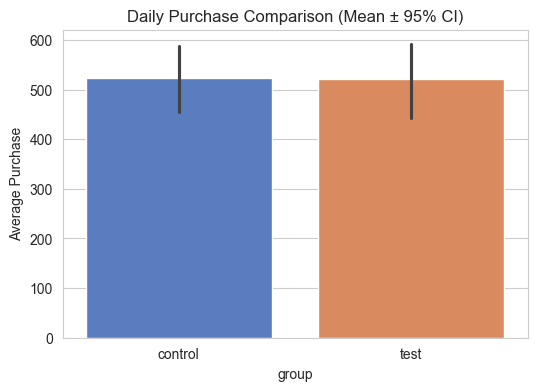

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(x='group', y='purchase', data=df, palette='muted', hue='group', legend=False)
plt.title('Daily Purchase Comparison (Mean ± 95% CI)')
plt.ylabel('Average Purchase')
plt.show()

## 1. Thiết lập Giả thuyết

Chúng ta muốn kiểm định xem số lượng đơn hàng trung bình hàng ngày có khác biệt có ý nghĩa thống kê giữa nhóm chiến dịch Control và Test hay không.

Gọi $\mu_C$ là giá trị trung bình thực tế của số lượng đơn hàng hàng ngày của nhóm Control, và $\mu_T$ là giá trị trung bình thực tế của số lượng đơn hàng hàng ngày của nhóm Test.

- **Giả thuyết Không ($H_0$):** Không có sự khác biệt có ý nghĩa về số lượng đơn hàng hàng ngày giữa hai nhóm Control và Test.
  $$H_0: \mu_C = \mu_T \quad (\mu_C - \mu_T = 0)$$

- **Giả thuyết Đối ($H_1$):** Có sự khác biệt có ý nghĩa thống kê về số lượng đơn hàng hàng ngày giữa hai nhóm Control và Test.
  $$H_1: \mu_C \neq \mu_T \quad (\mu_C - \mu_T \neq 0)$$

Chúng ta thiết lập mức ý nghĩa $\alpha = 0.05$ (mức tin cậy 95%).

## 2. Kiểm tra các Giả định (Assumption Testing)

Trước khi áp dụng các kiểm định giả thuyết tham số, chúng ta cần kiểm tra các giả định về phân phối chuẩn (normality) và tính đồng nhất phương sai (equal variances).

In [5]:
# D'Agostino's K-squared test for normality
stat_c, p_c = normaltest(control['purchase'])
stat_t, p_t = normaltest(test['purchase'])

print(f"Normality Test (Control p-value): {p_c:.4f} -> {'Normal' if p_c >= 0.05 else 'Non-Normal'}")
print(f"Normality Test (Test p-value):    {p_t:.4f} -> {'Normal' if p_t >= 0.05 else 'Non-Normal'}")

Normality Test (Control p-value): 0.0557 -> Normal
Normality Test (Test p-value):    0.0054 -> Non-Normal


In [6]:
# Levene's test for equal variances
stat_l, p_l = levene(control['purchase'], test['purchase'])
print(f"Levene's Test (Equal variance p-value): {p_l:.4f} -> {'Equal Variance' if p_l >= 0.05 else 'Unequal Variance'}")

Levene's Test (Equal variance p-value): 0.2720 -> Equal Variance


## 3. Kiểm định Welch's t-test

Vì phương sai giữa hai nhóm có thể không bằng nhau hoàn toàn, và tuân theo các thực hành tốt nhất về thống kê, chúng ta sẽ thực hiện Welch's t-test (`equal_var=False`), phép kiểm định không giả định phương sai bằng nhau giữa hai nhóm.

In [7]:
t_stat, p_val = ttest_ind(control['purchase'], test['purchase'], equal_var=False)
print(f"Welch's T-Statistic: {t_stat:.4f}")
print(f"P-Value:            {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("\n=> Reject Null Hypothesis (H0). There is a statistically significant difference between the two groups.")
else:
    print("\n=> Fail to Reject Null Hypothesis (H0). There is no statistically significant difference in daily purchases.")

Welch's T-Statistic: 0.0302
P-Value:            0.9760

=> Fail to Reject Null Hypothesis (H0). There is no statistically significant difference in daily purchases.


## 4. Khoảng tin cậy (Confidence Intervals)

Thay vì tính toán khoảng tin cậy của giá trị trung bình trên toàn bộ tập dữ liệu gộp chung (điều này sai về mặt khái niệm khi so sánh các nhóm A/B test), chúng ta tính toán:
1. Khoảng tin cậy 95% riêng biệt cho từng nhóm Control và Test.
2. Khoảng tin cậy 95% cho hiệu số giữa giá trị trung bình của hai nhóm Control và Test.

In [8]:
def calculate_ci(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    margin_error = se * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean, mean - margin_error, mean + margin_error

c_mean, c_lower, c_upper = calculate_ci(control['purchase'])
t_mean, t_lower, t_upper = calculate_ci(test['purchase'])

print(f"Control Group 95% CI of the Mean: [{c_lower:.2f}, {c_upper:.2f}] (Mean = {c_mean:.2f})")
print(f"Test Group 95% CI of the Mean:    [{t_lower:.2f}, {t_upper:.2f}] (Mean = {t_mean:.2f})")

# Calculate CI for the difference in means (Welch-Satterthwaite approach)
mean_diff = t_mean - c_mean
n1, n2 = len(control), len(test)
s1, s2 = control['purchase'].std(), test['purchase'].std()
se_diff = np.sqrt((s1**2 / n1) + (s2**2 / n2))

# Degrees of freedom for Welch-Satterthwaite
df = ((s1**2 / n1) + (s2**2 / n2))**2 / (((s1**2 / n1)**2 / (n1 - 1)) + ((s2**2 / n2)**2 / (n2 - 1)))
moe_diff = se_diff * stats.t.ppf(0.975, df)
diff_lower = mean_diff - moe_diff
diff_upper = mean_diff + moe_diff

print(f"\n95% CI of the Difference in Means (Test - Control): [{diff_lower:.2f}, {diff_upper:.2f}] (Diff = {mean_diff:.2f})")

Control Group 95% CI of the Mean: [452.41, 593.17] (Mean = 522.79)
Test Group 95% CI of the Mean:    [442.43, 600.04] (Mean = 521.23)

95% CI of the Difference in Means (Test - Control): [-104.96, 101.84] (Diff = -1.56)


## 5. Kích thước hiệu ứng - Effect Size (Cohen's d)

Chúng ta tính toán chỉ số Cohen's d để xác định mức độ chuẩn hóa của sự khác biệt giữa giá trị trung bình của hai chiến dịch.
Các ngưỡng đánh giá Cohen's d:
- $|d| < 0.2$: Rất nhỏ / Không đáng kể (Negligible)
- $0.2 \le |d| < 0.5$: Nhỏ (Small)
- $0.5 \le |d| < 0.8$: Trung bình (Medium)
- $|d| \ge 0.8$: Lớn (Large)

In [9]:
n1, n2 = len(control), len(test)
std1, std2 = control['purchase'].std(), test['purchase'].std()

pooled_std = np.sqrt(
    ((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2)
)

control_mean = control['purchase'].mean()
test_mean = test['purchase'].mean()
cohens_d = (test_mean - control_mean) / pooled_std
abs_d = abs(cohens_d)

if abs_d < 0.2:
    interpretation = "Negligible"
elif abs_d < 0.5:
    interpretation = "Small"
elif abs_d < 0.8:
    interpretation = "Medium"
else:
    interpretation = "Large"

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Effect Size Interpretation: {interpretation}")

Cohen's d: -0.0079
Effect Size Interpretation: Negligible


## 6. Tổng hợp Kết quả Kiểm định

Hãy tổng hợp các phát hiện của chúng ta dưới dạng bảng rõ ràng.

In [10]:
summary_df = pd.DataFrame({
    'Metric': ['Mean Purchase', 'Daily Spend (USD)'],
    'Control Mean': [control['purchase'].mean(), control['spend_usd'].mean()],
    'Test Mean': [test['purchase'].mean(), test['spend_usd'].mean()],
    'P-value (Welch t-test)': [p_val, ttest_ind(control['spend_usd'], test['spend_usd'], equal_var=False)[1]],
    'Significant (p < 0.05)': ['Yes' if p_val < 0.05 else 'No', 'Yes' if ttest_ind(control['spend_usd'], test['spend_usd'], equal_var=False)[1] < 0.05 else 'No']
}).round(4)
print(summary_df.to_string(index=False))

           Metric  Control Mean  Test Mean  P-value (Welch t-test) Significant (p < 0.05)
    Mean Purchase      522.7931   521.2333                  0.9760                     No
Daily Spend (USD)     2304.0690  2563.0667                  0.0071                    Yes
